 # Lesson 13 - Exercises for SVD

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec # for the subplots

# Exercise 1

Compute the SVD for the matrix M defined below.

In [13]:
M = np.array([[1, 2], [3, 4], [5, 6]])
U, S, VT = np.linalg.svd(M)

Sigma = np.zeros_like(M, dtype=float)
np.fill_diagonal(Sigma, S)


assert(np.allclose(M, U @ Sigma @ VT))

# Exercise 2

Check if the matrices U, S and Vt you computed in Exercise 1 reconstruct the original matrix M.
     

In [15]:
print("They don't construct directly. Sigma needs to be constructed from the S part of the function. You can see how this is done in exercise 1.")

assert(np.allclose(M, U @ Sigma @ VT))

They don't construct directly. Sigma needs to be constructed from the S part of the function. You can see how this is done in exercise 1.


# Exercise 3 (SVD for Low-Rank Approximations)

**This exercise has 4 questions at the end!!**

In this exercise we will use SVD to approximate an original image. We will use a drawing of Stravinsky by none other than the great Pablo Picasso. In the following code we use an
image of this drawing  that is available on Wikipedia.

Like with other images, it is natively a 3D tensor (640 × 430 × 3), but we will convert it to grayscale (2D matrix) for convenience.


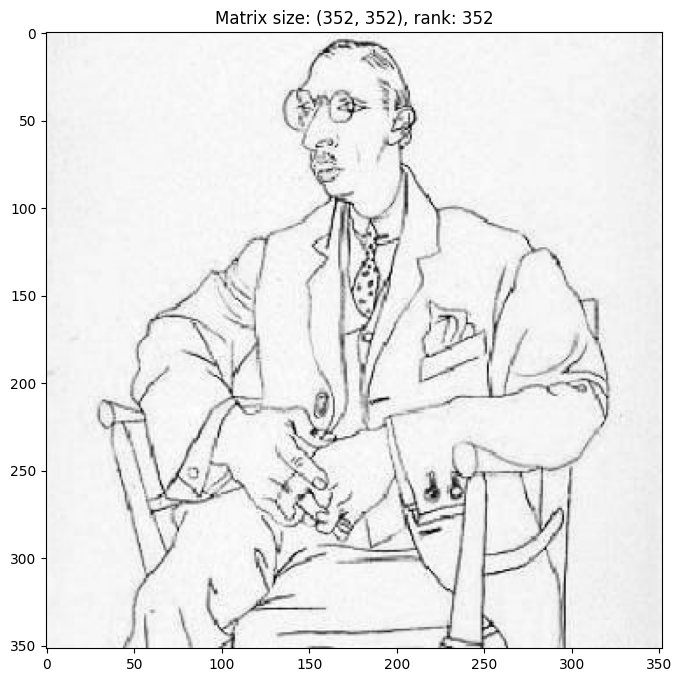

In [27]:
from skimage import io,color
url = 'https://gbaike-image.cdn.bcebos.com/6a600c338744ebf806b27e92d9f9d72a6159a75f/6a600c338744ebf806b27e92d9f9d72a6159a75f_1_1?x-bce-process=image/format,f_auto'

# import picture and downsample to 2D
strav = io.imread(url) / 255
strav = color.rgb2gray(strav)

plt.figure(figsize=(8,8))
plt.imshow(strav,cmap='gray')
plt.title(f'Matrix size: {strav.shape}, rank: {np.linalg.matrix_rank(strav)}')
plt.show()



In the following code we create a figure containing:

* The original matrix
* A scree plot which is the singular values normalized to percent
variance explained. Notice how the first few components account for most of the
variance in the image, while the later components each account for relatively little
variance.
* The first twelve “layers”—rank-1 matrices defined as $u_i σ_i v^T_i$  L0, L1, ..., L11
* The cumulative sum of those layers on the bottom row. Ex: L0:3=L0+L1+L2+L3

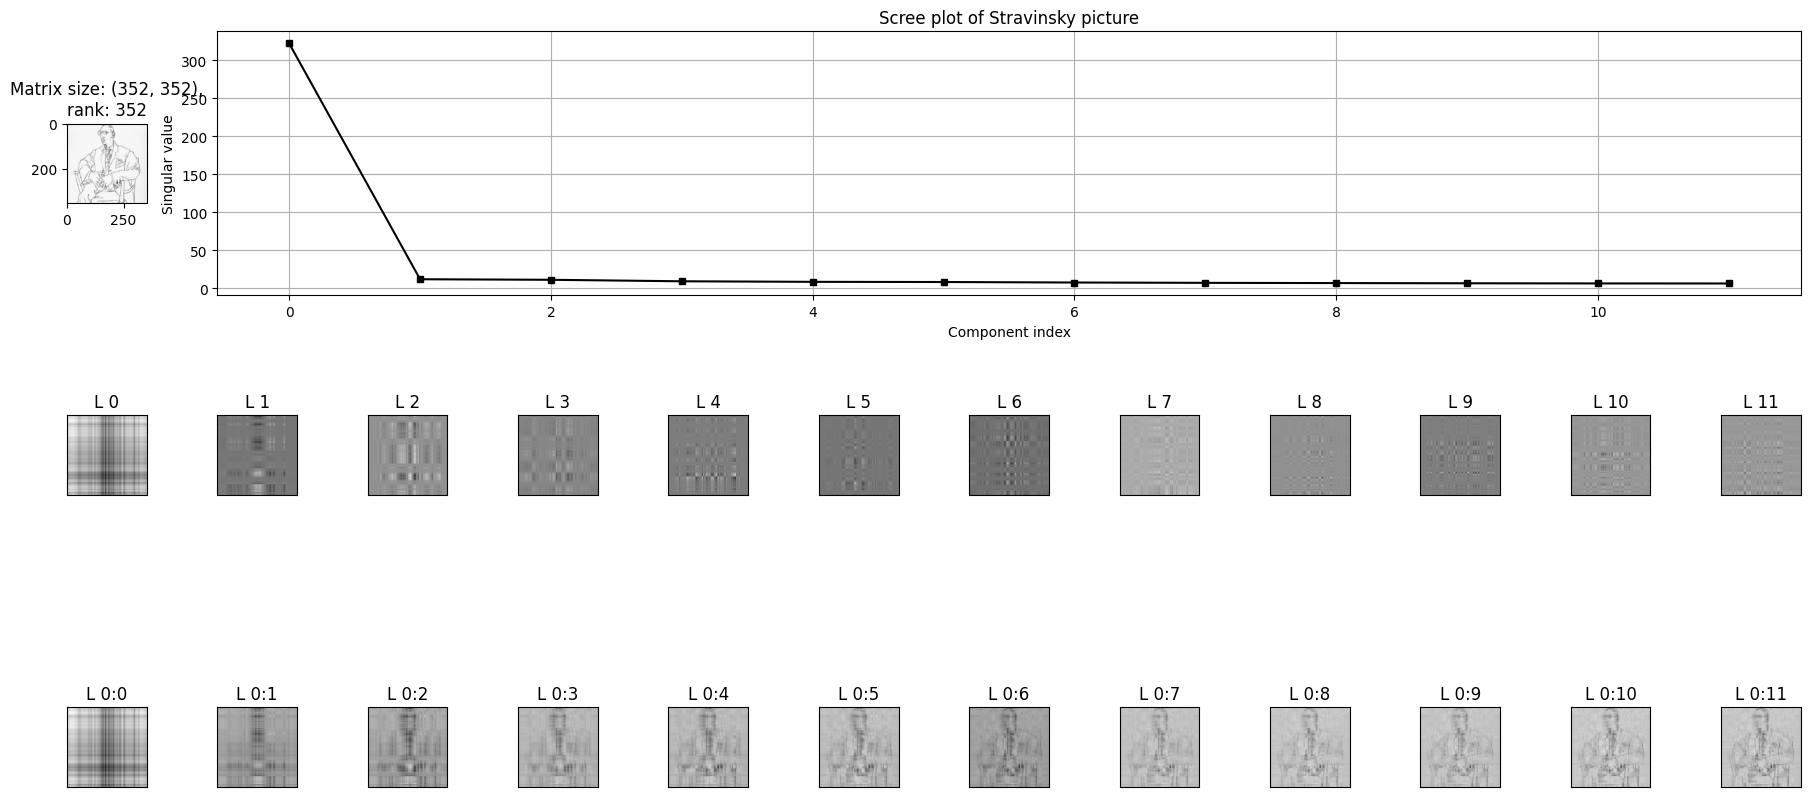

In [34]:
# SVD
U,s,Vt = np.linalg.svd(strav)
S = np.zeros_like(strav)
np.fill_diagonal(S,s)


fig = plt.figure(figsize=(18,9))
gs = GridSpec(3,12,figure=fig)

# the image
ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(strav,cmap='gray')
ax1.set_title(f'Matrix size: {strav.shape},\nrank: {np.linalg.matrix_rank(strav)}')


# scree plot
ax2 = fig.add_subplot(gs[0,1:])
ax2.plot(s[:12],'ks-',markersize=5)
ax2.set_xlabel('Component index')
ax2.set_ylabel('Singular value')
ax2.set_title('Scree plot of Stravinsky picture')
ax2.grid()


## now show the first N "layers" separately
numLayers = 12
rank1mats = np.zeros((numLayers,strav.shape[0],strav.shape[1]))


# the loop
for i in range(numLayers):

    # create this layer
    rank1mats[i,:,:] = np.outer(U[:,i],Vt[i,:])*s[i]

    # show this layer
    ax = fig.add_subplot(gs[1,i])
    ax.imshow(rank1mats[i,:,:],cmap='gray')
    ax.set_title(f'L {i}')
    ax.set_xticks([]), ax.set_yticks([])

    # show the cumulative sum of layers
    ax = fig.add_subplot(gs[2,i])
    ax.imshow(np.sum(rank1mats[:i+1,:,:],axis=0),cmap='gray')
    ax.set_title(f'L 0:{i}')
    ax.set_xticks([]), ax.set_yticks([])


plt.tight_layout()
plt.show()


You can see that each layer adds more information to the matrix.

Test your knowledge by answering the following questions:

1. What is the relation between the points in the scree plot and the rank-1 matrices L i ? Ex. relation between the first point and L0?
2. What is the relation between the cumulative sum of layers and the original figure? Ex. Relation between L0:5 and the matrix.
3. What will happen if we continue adding layers. For example what do you expect to happen at L0:40?
4. What is the maximum number of points that we can plot in the scree plot?



# Exercise 4

Create your own figure for the scree plot making sure it contains all the possible values

# Exercise 5

1. Change your scree plot to show only the last 10 points.
2. What can you say about the influence of such values in the reconstruction result?
3. Create your own L 429 matrix
4. Print L 429

# Exercise 6

In Exercise 3,  the rank-8 approximation is terrible as a reconstruction of the Stravinsky drawing. It looks nothing like the original image.
The goal of this exercise is to reconstruct the image using more layers so that the low-rank approximation is reasonably accurate—and then compute the amount of
compression obtained.

Start by producing the next figure, which shows the original image, the reconstructed
image, and the error map, which is the squared difference between the original and
the approximation. For this figure, I chose k = 80 components, but I encourage you to
explore different values (that is, different rank approximations).

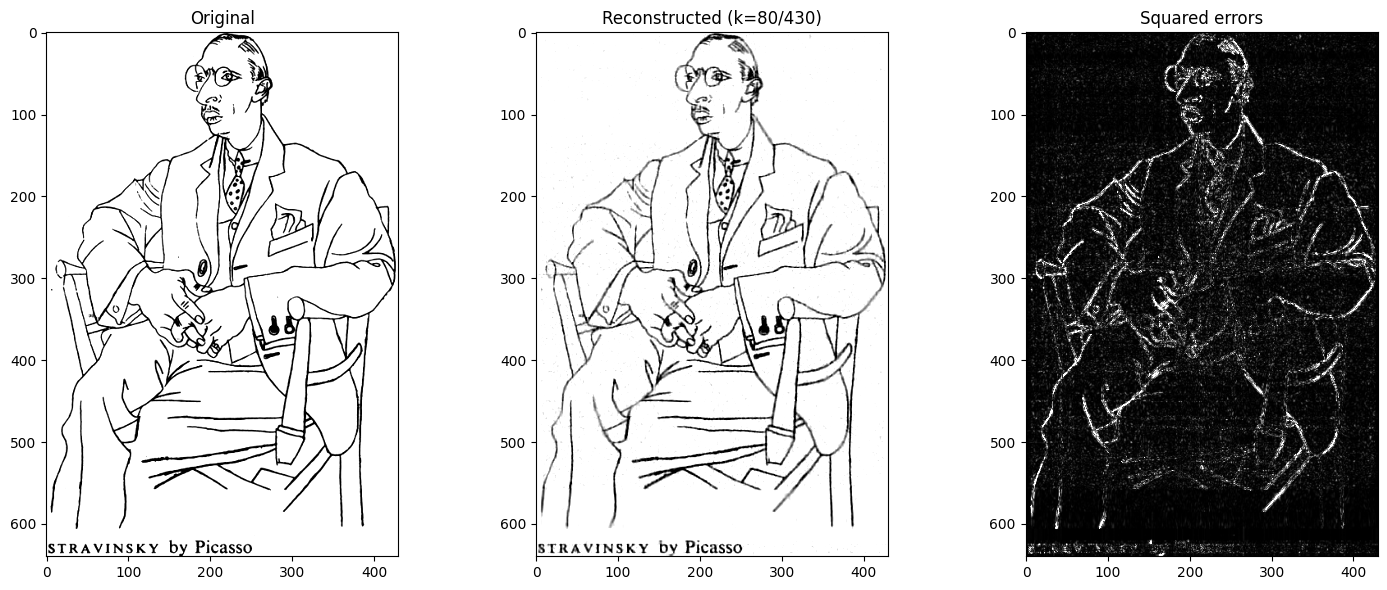

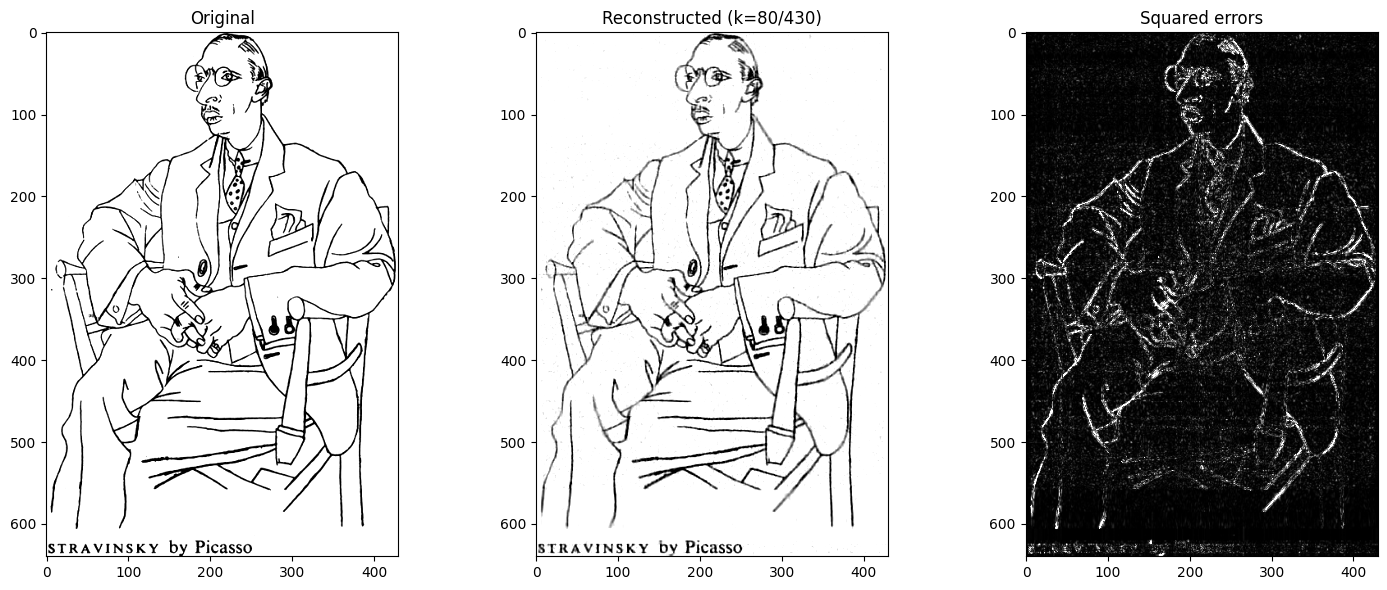

In [ ]:


# Reconstruct based on first k layers

# number of components
k = 80

# reconstruction
stravRec = U[:,:k] @ S[:k,:k] @ Vt[:k,:]


# show the original, reconstructed, and error
_,axs = plt.subplots(1,3,figsize=(15,6))

axs[0].imshow(strav,cmap='gray',vmin=.1,vmax=.9)
axs[0].set_title('Original')

axs[1].imshow(stravRec,cmap='gray',vmin=.1,vmax=.9)
axs[1].set_title(f'Reconstructed (k={k}/{len(s)})')

axs[2].imshow((strav-stravRec)**2,cmap='gray',vmin=0,vmax=1e-1)
axs[2].set_title('Squared errors')

plt.tight_layout()
plt.savefig('Figure_15_10.png',dpi=300)
plt.show()



# Exercise 7

Compute the compression, which is the percentage of the number of bytes
used by the low-rank approximation versus the number of bytes used by the original image.

The results for k = 80 are shown here. Keep in mind that with low-rank
approximations, you don't need to store the full image or the full SVD matrices! You just need to store the vector $s$, and the matrices $U$ and $Vt$.

* Original is 2.10 mb
* Reconstruction is 2.10 mb
* Recon vectors are 0.65 mb (using k=80 comps.)
* Compression of 31.13%

You can use the nbytes function in python. For instance for the matrix M defined above with 6 entries we obtain:

```
M.nbytes
48
```


# Exercise 8

Show how to derive the singular values and left singular vectors from eigendecomposition.

# Exercise 9

Assuming that $S = A^T A$ and that the SVD of S is $U \Sigma V^T$.

Show that $U \Sigma V^T = V \Sigma U^T$.  

Hint: Use the fact that $S = S^T$.
